# Deep Learning Primitives and Shallow Networks

### 23AIML042

You are part of a research team tasked with migrating traditional NLP methods (like N-Grams) to modern neural network architectures. Before building complex models like RNNs, you must first master the fundamental mathematical components that allow any deep learning model to learn.

Your primary goal is to implement and visualize the key functions (Activation, Loss, Optimization) and then integrate them into a simple, fully-connected (shallow) network using a modern framework (PyTorch).


## Import required libraries

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


## Tasks

### Task 1: Activation Function Implementation (Sigmoid)
The activation function is crucial for introducing non-linearity into the network, allowing it to learn complex patterns.
Implement the `sigmoid(x)` function using numpy:

 - Generate input values  from -10 to 10 and calculate the corresponding Sigmoid output.
 - Plot the Sigmoid Activation Function using matplotlib to visualize its non-linear S-shape and saturation behavior.

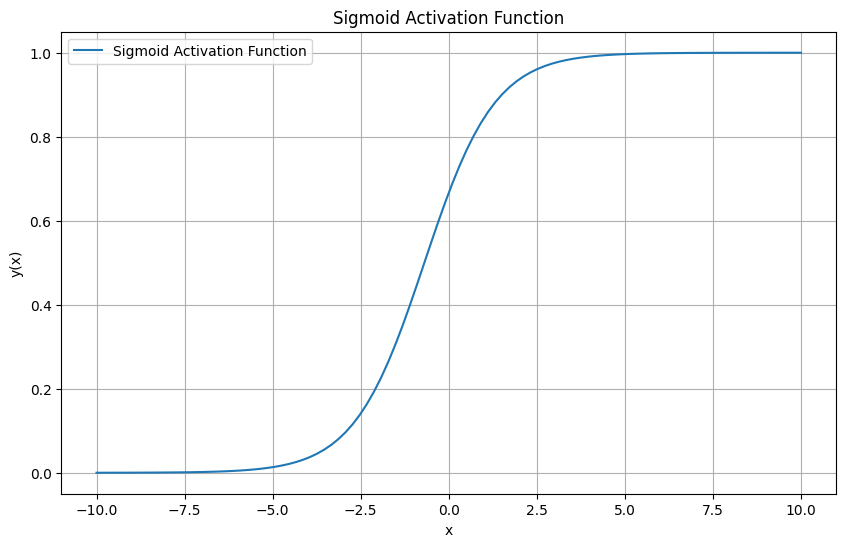

In [ ]:
def sigmoid(x):
    return  1 / (1 + np.exp(-x))

x = np.linspace(-10, 10, 100)
y_sigmoid = sigmoid(x)

plt.figure(figsize=(10, 6))
plt.plot(x, y_sigmoid, label='Sigmoid Activation Function')
plt.xlabel('x')
plt.ylabel('y(x)')
plt.title('Sigmoid Activation Function')
plt.grid(True)
plt.legend()
plt.show()

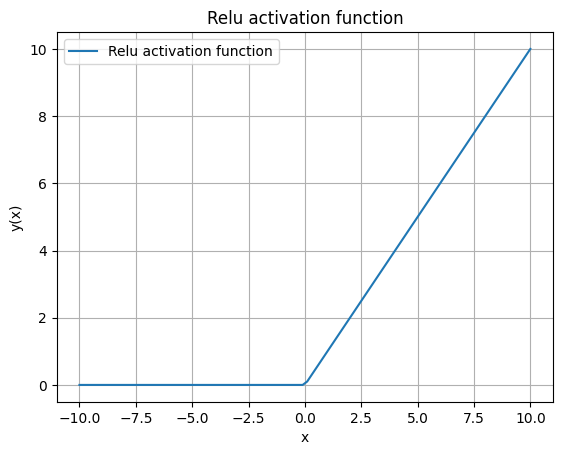

In [9]:
# new activation function
def relu(x):
    return np.maximum(0, x)

x = np.linspace(-10, 10, 100)
y_relu = relu(x)

plt.Figure(figsize=(10, 10))
plt.plot(x, y_relu, label= 'Relu activation function')
plt.xlabel('x')
plt.ylabel('y(x)')
plt.title('Relu activation function')
plt.grid(True)
plt.legend()
plt.show()

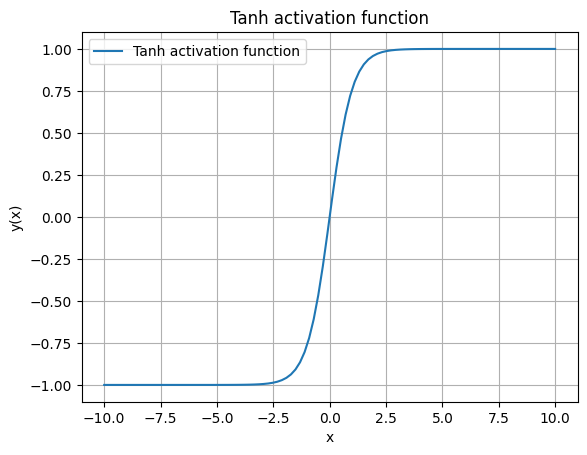

In [10]:
# Tanh activation function
def tanh(x):
    return np.tanh(x)

x = np.linspace(-10, 10, 100)
y_tanh = tanh(x)

plt.Figure(figsize=(10, 10))
plt.plot(x, y_tanh, label= 'Tanh activation function')
plt.xlabel('x')
plt.ylabel('y(x)')
plt.title('Tanh activation function')
plt.grid(True)
plt.legend()
plt.show()

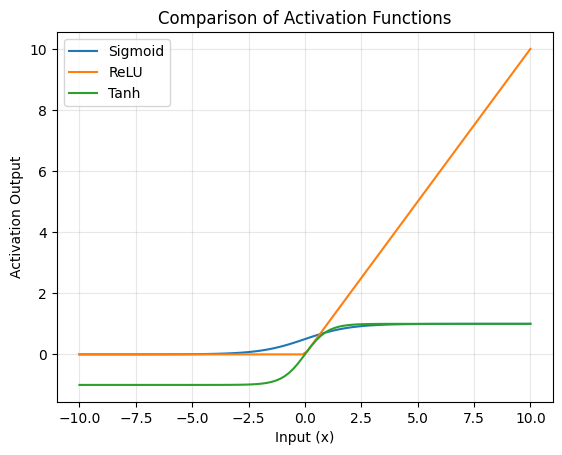

In [11]:
sns.lineplot(x=x, y=y_sigmoid, label='Sigmoid')
sns.lineplot(x=x, y=y_relu, label='ReLU')
sns.lineplot(x=x, y=y_tanh, label='Tanh')

plt.xlabel('Input (x)')
plt.ylabel('Activation Output')
plt.title('Comparison of Activation Functions')
plt.grid(True, alpha=0.3) # Added alpha for better readability
plt.legend()
plt.show()

### Task 2: Loss Function Definition (Mean Squared Error)
The loss function quantifies the difference between the model's prediction and the true value.
 - Define the loss function `def loss_function(x)`, which is $ y = x^2$
 - Deinfe the Gradiant function `def gradiant(x)`, which is $ y = 2x $

 - Implement and Visualise the Gradient Descent Algorithm Implement a generic `gradient_descent(loss_function, gradient, start_x, learning_rate, iterations)` function.
 - Use the provided `loss_function(x)` function and its gradient to simulate the iterative update process.
 - Run the optimizer for a set number of iterations (e.g., 100), printing the x value, Loss, and Gradient at each step to demonstrate convergence to the minimum.


#### Import Required Libraries

In [12]:
import numpy as np
import matplotlib.pyplot as plt

#### Define Loss Function and Gradient

In [13]:
# Define a simple quadratic loss function: y = x^2
def loss_function(x):
    return x**2

# Derivative of the loss function: dy/dx = 2x
def gradient(x):
    return 2*x

#### Gardient Descent Formulae: new = old - learning rate * slope


#### Gradient Descent Algorithm

In [14]:
# Gradient Descent Algorithm
def gradient_descent(starting_point, learning_rate, iterations):
  x = starting_point  # Initial value
  history = []        # To store x values and corresponding loss
  for i in range(iterations):
    loss = loss_function(x)
    gradient_value = gradient(x)
    history.append((x,loss))
    # Update x using gradient descent formula
    x -= learning_rate*gradient_value
    if i%5 == 0:
      print(f"Iteration {i+1}: x = {x:.4f}, Loss = {loss:.4f}, Gradient = {gradient_value:.4f}")

  return history

#### Parameters for Gradient Descent

In [15]:
starting_point = 10  # Starting point for x
learning_rate = 0.08 # Step size for gradient descent
iterations = 300      # Number of iterations

#### Run Gradient Descent

In [16]:
history = gradient_descent(starting_point, learning_rate, iterations)

Iteration 1: x = 8.4000, Loss = 100.0000, Gradient = 20.0000
Iteration 6: x = 3.5130, Loss = 17.4901, Gradient = 8.3642
Iteration 11: x = 1.4692, Loss = 3.0590, Gradient = 3.4980
Iteration 16: x = 0.6144, Loss = 0.5350, Gradient = 1.4629
Iteration 21: x = 0.2570, Loss = 0.0936, Gradient = 0.6118
Iteration 26: x = 0.1075, Loss = 0.0164, Gradient = 0.2559
Iteration 31: x = 0.0449, Loss = 0.0029, Gradient = 0.1070
Iteration 36: x = 0.0188, Loss = 0.0005, Gradient = 0.0448
Iteration 41: x = 0.0079, Loss = 0.0001, Gradient = 0.0187
Iteration 46: x = 0.0033, Loss = 0.0000, Gradient = 0.0078
Iteration 51: x = 0.0014, Loss = 0.0000, Gradient = 0.0033
Iteration 56: x = 0.0006, Loss = 0.0000, Gradient = 0.0014
Iteration 61: x = 0.0002, Loss = 0.0000, Gradient = 0.0006
Iteration 66: x = 0.0001, Loss = 0.0000, Gradient = 0.0002
Iteration 71: x = 0.0000, Loss = 0.0000, Gradient = 0.0001
Iteration 76: x = 0.0000, Loss = 0.0000, Gradient = 0.0000
Iteration 81: x = 0.0000, Loss = 0.0000, Gradient = 0.

#### Visualization of Gradient Descent

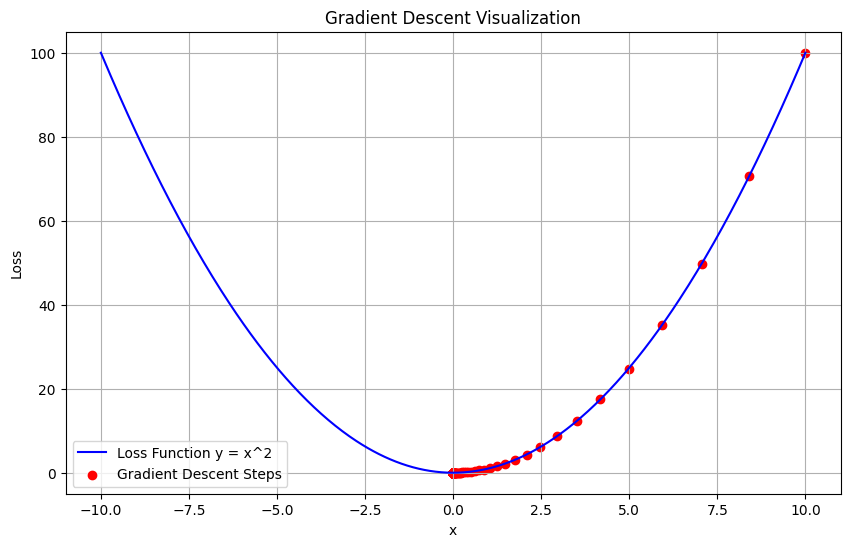

In [17]:
# Extract x and loss values for plotting
x_values, loss_values = zip(*history)

# Plotting the Loss Function
x_plot = np.linspace(-10, 10, 500)
y_plot = loss_function(x_plot)

plt.figure(figsize=(10, 6))
plt.plot(x_plot, y_plot, label='Loss Function y = x^2', color='blue')
plt.scatter(x_values, loss_values, color='red', label='Gradient Descent Steps')
plt.title('Gradient Descent Visualization')
plt.xlabel('x')
plt.ylabel('Loss')
plt.legend()
plt.grid()
plt.show()

### Task 3: Building a Shallow DNN in PyTorch
Translate the mathematical primitives into a functional PyTorch model.

![image](https://matthewmazur.files.wordpress.com/2018/03/neural_network-9.png)

Define a class SimpleDNN that inherits from torch.nn.Module.
Construct a simple network with two layers:
- An input layer  a hidden layer (e.g., 2 input features, 2 hidden units).
- A hidden layer  an output layer (e.g., 2 hidden units, 1 output unit).
- Use the Sigmoid activation function on the output layer to ensure the output is between 0 and 1, suitable for binary classification probability.
- Write the forward() method and test it with a sample input tensor (e.g., torch.Tensor([0.05, 0.10])).



- [Source_blog](https://mattmazur.com/2015/03/17/a-step-by-step-backpropagation-example/)

In [18]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy
from sklearn import datasets

In [19]:
m = nn.Linear(20, 30)

In [20]:
m

Linear(in_features=20, out_features=30, bias=True)

In [21]:
nn.Linear

torch.nn.modules.linear.Linear

In [22]:
m = nn.Linear(2, 3)
input = torch.randn(3, 2)
output = m(input)


In [23]:
input

tensor([[-0.0896,  0.3792],
        [-2.2119,  0.2730],
        [-1.2882, -0.2903]])

In [24]:
output

tensor([[-0.3295, -0.7339, -0.7751],
        [-0.1039, -0.8799, -1.3224],
        [ 0.1633, -0.4350, -0.6607]], grad_fn=<AddmmBackward0>)

In [25]:
output.shape

torch.Size([3, 3])

In [26]:
m.weight.data

tensor([[-0.0763, -0.5993],
        [ 0.1001, -0.6256],
        [ 0.2926, -0.6946]])

In [27]:
m.bias.data

tensor([-0.1090, -0.4877, -0.4854])

In [28]:
def init_weight(m):
    if type(m) in [nn.Conv2d,nn.Linear]:
        m.weight.data=torch.Tensor([[0.15,0.20],[0.25,0.30]])
        m.bias.data=torch.Tensor([0.35])

In [29]:
## Model Set Up
class Perceptron(nn.Module):
  def __init__(self,input_size,H1,output_size):
      super().__init__()

      self.linear = nn.Linear(input_size,H1)
      self.linear.weight.data=torch.Tensor([[0.15,0.20],[0.25,0.30]])
      self.linear.bias.data = torch.Tensor([0.35])

      self.linear2 = nn.Linear(H1,output_size)
      self.linear2.weight.data=torch.Tensor([[0.40,0.45],[0.50,0.55]])
      self.linear2.bias.data = torch.Tensor([0.60])

  def forward(self,x, print_values=True):
      net_h = self.linear(x)
      out_h = torch.sigmoid(net_h)
      net_O = self.linear2(out_h)
      out_O = torch.sigmoid(net_O)

      if print_values:
          print("h1: {}, h2: {}".format(net_h[0], net_h[1]))
          print("out_h1: {}, out_h2: {}".format(out_h[0], out_h[1]))
          print("net_O1: {}, net_O2: {}".format(net_O[0], net_O[1]))
          print("out_O1: {}, out_O2: {}".format(out_O[0], out_O[1]))


      return (out_O)

## Unfold each epoch and check intermediate values


### Initial Weight of the model

In [30]:
model=Perceptron(2,2,1)
print (list(model.parameters()))

[Parameter containing:
tensor([[0.1500, 0.2000],
        [0.2500, 0.3000]], requires_grad=True), Parameter containing:
tensor([0.3500], requires_grad=True), Parameter containing:
tensor([[0.4000, 0.4500],
        [0.5000, 0.5500]], requires_grad=True), Parameter containing:
tensor([0.6000], requires_grad=True)]


### After 1 forward pass check hidden, output and loss

![image](https://matthewmazur.files.wordpress.com/2018/03/neural_network-9.png)

In [31]:
model.forward(torch.Tensor([0.05,0.10]))

h1: 0.3774999976158142, h2: 0.39249998331069946
out_h1: 0.5932700037956238, out_h2: 0.5968843698501587
net_O1: 1.1059060096740723, net_O2: 1.224921464920044
out_O1: 0.751365065574646, out_O2: 0.7729284763336182


tensor([0.7514, 0.7729], grad_fn=<SigmoidBackward0>)

$$\ell(x, y) = L = \{l_1,\dots,l_N\}^\top, \quad l_n = \left( x_n - y_n \right)^2,$$

In [32]:
nn.MSELoss

torch.nn.modules.loss.MSELoss

In [33]:
model=Perceptron(2,2,2)
criterion=nn.MSELoss()
optimizer=torch.optim.SGD(model.parameters(),lr=0.5)
output=model.forward(torch.Tensor([0.05,0.10]))
target=torch.Tensor([0.01,0.99])
loss=criterion(output,target)
print("total MSEerror: {}".format(loss.item()))

h1: 0.3774999976158142, h2: 0.39249998331069946
out_h1: 0.5932700037956238, out_h2: 0.5968843698501587
net_O1: 1.1059060096740723, net_O2: 1.224921464920044
out_O1: 0.751365065574646, out_O2: 0.7729284763336182
total MSEerror: 0.2983711063861847


### Backward pass

In [34]:
# set prev grad to zero
optimizer.zero_grad()

loss.backward()

optimizer.step()

print(list(model.parameters()))

[Parameter containing:
tensor([[0.1498, 0.1996],
        [0.2498, 0.2995]], requires_grad=True), Parameter containing:
tensor([0.3406], requires_grad=True), Parameter containing:
tensor([[0.3589, 0.4087],
        [0.5113, 0.5614]], requires_grad=True), Parameter containing:
tensor([0.5498], requires_grad=True)]


### 2nd Forward Pass

In [35]:
y_output = model.forward(torch.Tensor([0.05,0.10]))

h1: 0.36808234453201294, h2: 0.38307496905326843
out_h1: 0.5909954905509949, out_h2: 0.594614565372467
net_O1: 1.0049166679382324, net_O2: 1.1857755184173584
out_O1: 0.7320241332054138, out_O2: 0.7659847140312195


### 2nd Backward pass

In [36]:
loss=criterion(y_output,target)

optimizer.zero_grad()

loss.backward()

optimizer.step()

print(list(model.parameters()))

[Parameter containing:
tensor([[0.1496, 0.1992],
        [0.2495, 0.2991]], requires_grad=True), Parameter containing:
tensor([0.3327], requires_grad=True), Parameter containing:
tensor([[0.3171, 0.3666],
        [0.5232, 0.5733]], requires_grad=True), Parameter containing:
tensor([0.4991], requires_grad=True)]


## Reinitializing the model and looping over Epoch

In [37]:
model=Perceptron(2,2,2)
criterion=nn.MSELoss()
optimizer=torch.optim.SGD(model.parameters(),lr=0.5)

input_x = torch.Tensor([0.05,0.10])
epoch = 200
for i in range(epoch):
    y_output=model.forward(input_x)

    loss=criterion(y_output,target)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if i%10 == 0:
        print(f'Epoch: {i}, loss: {loss.item()}, output: {y_output}')
        print("="*60)

h1: 0.3774999976158142, h2: 0.39249998331069946
out_h1: 0.5932700037956238, out_h2: 0.5968843698501587
net_O1: 1.1059060096740723, net_O2: 1.224921464920044
out_O1: 0.751365065574646, out_O2: 0.7729284763336182
Epoch: 0, loss: 0.2983711063861847, output: tensor([0.7514, 0.7729], grad_fn=<SigmoidBackward0>)
h1: 0.36808234453201294, h2: 0.38307496905326843
out_h1: 0.5909954905509949, out_h2: 0.594614565372467
net_O1: 1.0049166679382324, net_O2: 1.1857755184173584
out_O1: 0.7320241332054138, out_O2: 0.7659847140312195
h1: 0.360114723443985, h2: 0.37509986758232117
out_h1: 0.5890681743621826, out_h2: 0.5926907062530518
net_O1: 0.9030864238739014, net_O2: 1.1470353603363037
out_O1: 0.7115833759307861, out_O2: 0.7589690089225769
h1: 0.35378366708755493, h2: 0.3687613606452942
out_h1: 0.5875347852706909, out_h2: 0.5911596417427063
net_O1: 0.8010352849960327, net_O2: 1.1092110872268677
out_O1: 0.6901959180831909, out_O2: 0.7519819736480713
h1: 0.349249929189682, h2: 0.3642202615737915
out_h1: 

**Note:** at Line 3 above, if we use `Adam` optimizer, it will learn faster in lesser epoch. For example, with Adam, only using 10 epochs, the model will learn the optimum weight

In [38]:
print(list(model.parameters()))

[Parameter containing:
tensor([[0.1798, 0.2596],
        [0.2793, 0.3585]], requires_grad=True), Parameter containing:
tensor([1.5313], requires_grad=True), Parameter containing:
tensor([[-1.3960, -1.3548],
        [ 1.7382,  1.7937]], requires_grad=True), Parameter containing:
tensor([-0.3141], requires_grad=True)]


## Prediction

In [39]:
print (model.forward(torch.Tensor([0.06,0.12])))

h1: 1.573275089263916, h2: 1.5911091566085815
out_h1: 0.828249990940094, out_h2: 0.8307720422744751
net_O1: -2.5958445072174072, net_O2: 2.615769863128662
out_O1: 0.06940633803606033, out_O2: 0.9318695664405823
tensor([0.0694, 0.9319], grad_fn=<SigmoidBackward0>)
